# PKCERT Task 08 – Classification Models: Logistic Regression, Decision Trees & Random Forests

**Objective:** Develop practical skills in building and evaluating classification models using
Logistic Regression, Decision Trees, and Random Forests, and learn to evaluate model performance
using classification metrics.

**Dataset:** scikit-learn's built-in **Breast Cancer Wisconsin (Diagnostic)** dataset — 569
samples, 30 numeric features computed from digitized images of breast masses, binary target
(`malignant` = 0, `benign` = 1). It's a clean, well-known public classification dataset with no
missing values, which keeps the focus on modeling and evaluation rather than data cleaning.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)

import os
os.makedirs("visualizations", exist_ok=True)

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", plt.matplotlib.__version__)
print("seaborn:", sns.__version__)
print("scikit-learn:", sklearn.__version__)


numpy: 1.26.4
pandas: 2.1.4
matplotlib: 3.8.0
seaborn: 0.12.2
scikit-learn: 1.2.2


## Part A – Logistic Regression (30 Marks)

### A.1 Select a Public Classification Dataset

Using `sklearn.datasets.load_breast_cancer`: 569 rows, 30 features (mean/standard-error/worst
values of radius, texture, perimeter, area, smoothness, etc.), binary target.

In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

print("Shape:", df.shape)
print("\nTarget classes:", dict(zip(data.target_names, [0, 1])))
print("\nClass balance:")
print(df["target"].value_counts().rename(index={0: "malignant", 1: "benign"}))

df.head()


Shape: (569, 31)

Target classes: {'malignant': 0, 'benign': 1}

Class balance:
target
benign       357
malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


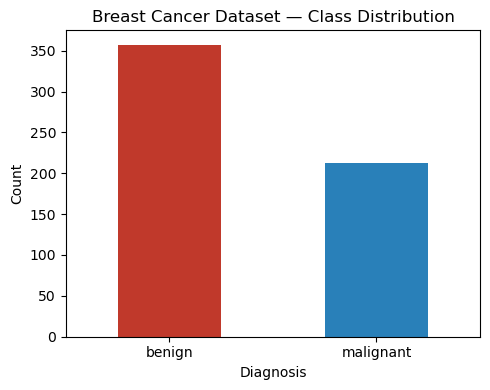

In [3]:
fig, ax = plt.subplots(figsize=(5, 4))
df["target"].map({0: "malignant", 1: "benign"}).value_counts().plot(
    kind="bar", color=["#c0392b", "#2980b9"], ax=ax
)
ax.set_title("Breast Cancer Dataset — Class Distribution")
ax.set_xlabel("Diagnosis")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("visualizations/1_class_distribution.png", dpi=150)
plt.show()


### A.2 Build a Logistic Regression Model

Split into train/test sets (80/20, stratified so both splits keep the same class ratio), scale
features with `StandardScaler` (logistic regression is sensitive to feature scale since it
optimizes a weighted sum of features), then fit `LogisticRegression`.

In [4]:
X = df.drop(columns="target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=10000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Logistic Regression test accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")


Train shape: (455, 30), Test shape: (114, 30)
Logistic Regression test accuracy: 0.9825


### A.3 Working Principle & Real-World Application

**How Logistic Regression works:** despite the name, it's a *classification* algorithm. It
computes a weighted linear combination of the input features (`z = w·x + b`), then passes `z`
through the **sigmoid function** `σ(z) = 1 / (1 + e^-z)`, which squashes any real number into a
probability between 0 and 1. The model predicts class 1 if `σ(z) ≥ 0.5`, else class 0. The
weights `w` and bias `b` are learned by maximizing the likelihood of the observed labels (via
gradient descent on the log-loss / cross-entropy cost function), not by minimizing squared error
like linear regression. The decision boundary it learns is linear in the feature space (a
hyperplane), which is why scaling and, where needed, feature engineering matter.

**Real-world application:** medical diagnosis — exactly what this dataset represents. A hospital
can use logistic regression on measurements from a biopsy (radius, texture, concavity, etc.) to
estimate the *probability* that a tumor is malignant, not just a hard yes/no. That probability
output is valuable clinically: a borderline case (e.g. 48% malignant) can be flagged for further
testing rather than being forced into a binary call. Other common uses: credit default
prediction, email spam filtering, and customer churn prediction — anywhere the outcome is binary
and a calibrated probability (not just a label) is useful.

## Part B – Classification Metrics (30 Marks)

### B.1 Accuracy, Precision, Recall, F1-Score

In [5]:
acc = accuracy_score(y_test, y_pred_lr)
prec = precision_score(y_test, y_pred_lr)
rec = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)
rec_malignant = recall_score(y_test, y_pred_lr, pos_label=0)

print(f"Accuracy:              {acc:.4f}")
print(f"Precision (benign):    {prec:.4f}")
print(f"Recall (benign):       {rec:.4f}")
print(f"F1-Score (benign):     {f1:.4f}")
print(f"Recall (malignant):    {rec_malignant:.4f}  <- sensitivity for catching cancer")
print()
print(classification_report(y_test, y_pred_lr, target_names=["malignant", "benign"]))


Accuracy:              0.9825
Precision (benign):    0.9861
Recall (benign):       0.9861
F1-Score (benign):     0.9861
Recall (malignant):    0.9762  <- sensitivity for catching cancer

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



### B.2 Confusion Matrix

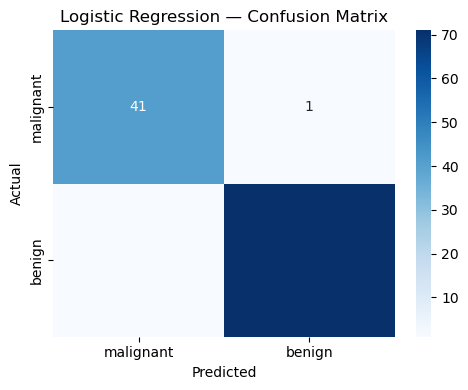

True Negatives (correctly predicted malignant):  41
False Positives (malignant predicted as benign):  1
False Negatives (benign predicted as malignant):  1
True Positives (correctly predicted benign):      71


In [6]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm_lr, annot=True, fmt="d", cmap="Blues",
    xticklabels=["malignant", "benign"], yticklabels=["malignant", "benign"], ax=ax,
)
ax.set_title("Logistic Regression — Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("visualizations/2_logistic_regression_confusion_matrix.png", dpi=150)
plt.show()

tn, fp, fn, tp = cm_lr.ravel()
print(f"True Negatives (correctly predicted malignant):  {tn}")
print(f"False Positives (malignant predicted as benign):  {fp}")
print(f"False Negatives (benign predicted as malignant):  {fn}")
print(f"True Positives (correctly predicted benign):      {tp}")


**Interpreting the confusion matrix:** the row is the true diagnosis, the column is the
model's prediction. `scikit-learn`'s binary metrics treat class **1 (benign)** as the "positive"
class by default, so with `confusion_matrix` returning `[[TN, FP], [FN, TP]]`:

- **False Positive** = true label malignant (0), predicted benign (1) — **this is the dangerous
  cell**: an actual cancer the model missed entirely.
- **False Negative** = true label benign (1), predicted malignant (0) — a false alarm: costly
  (unnecessary follow-up biopsy) but not dangerous.

Because of this label convention, the default `Recall` printed above is recall *for the benign
class*, not for malignant. The metric that actually measures "how many real cancers did we
catch" is **recall computed with `pos_label=0`** (printed separately above as
`Recall (malignant)`), which is the number to watch most closely in this dataset.

### B.3 Why Each Metric Matters
- **Accuracy** — overall fraction of correct predictions. Easy to read, but misleading on
  imbalanced data (e.g. 95% accuracy is meaningless if 95% of samples are one class).
- **Precision** — of everything predicted positive, how much was actually positive
  (`TP / (TP + FP)`). Matters when false positives are costly (e.g. flagging a healthy patient as
  sick, or marking a legitimate email as spam).
- **Recall (Sensitivity)** — of everything actually positive, how much was caught
  (`TP / (TP + FN)`). Matters when false negatives are costly — here, missing an actual malignant
  tumor (a false positive under sklearn's convention, since malignant=0 is the negative class) is
  the worst outcome, so recall computed for the **malignant** class specifically is critical, not
  just the default (benign) recall.
- **F1-Score** — the harmonic mean of precision and recall (`2·P·R / (P+R)`). Useful as a single
  number when you need a balance between the two and the classes are imbalanced, since it
  punishes extreme trade-offs (e.g. 100% recall but 1% precision scores poorly).

## Part C – Decision Trees & Random Forests (30 Marks)

### C.1 Decision Tree Classifier

A decision tree splits the data recursively on the feature/threshold that most reduces impurity
(Gini impurity by default in scikit-learn), producing a set of if/then rules. `max_depth=4` is
used here to keep the tree readable and reduce overfitting.

In [7]:
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print(f"Decision Tree test accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt, target_names=["malignant", "benign"]))


Decision Tree test accuracy: 0.9386
              precision    recall  f1-score   support

   malignant       0.91      0.93      0.92        42
      benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



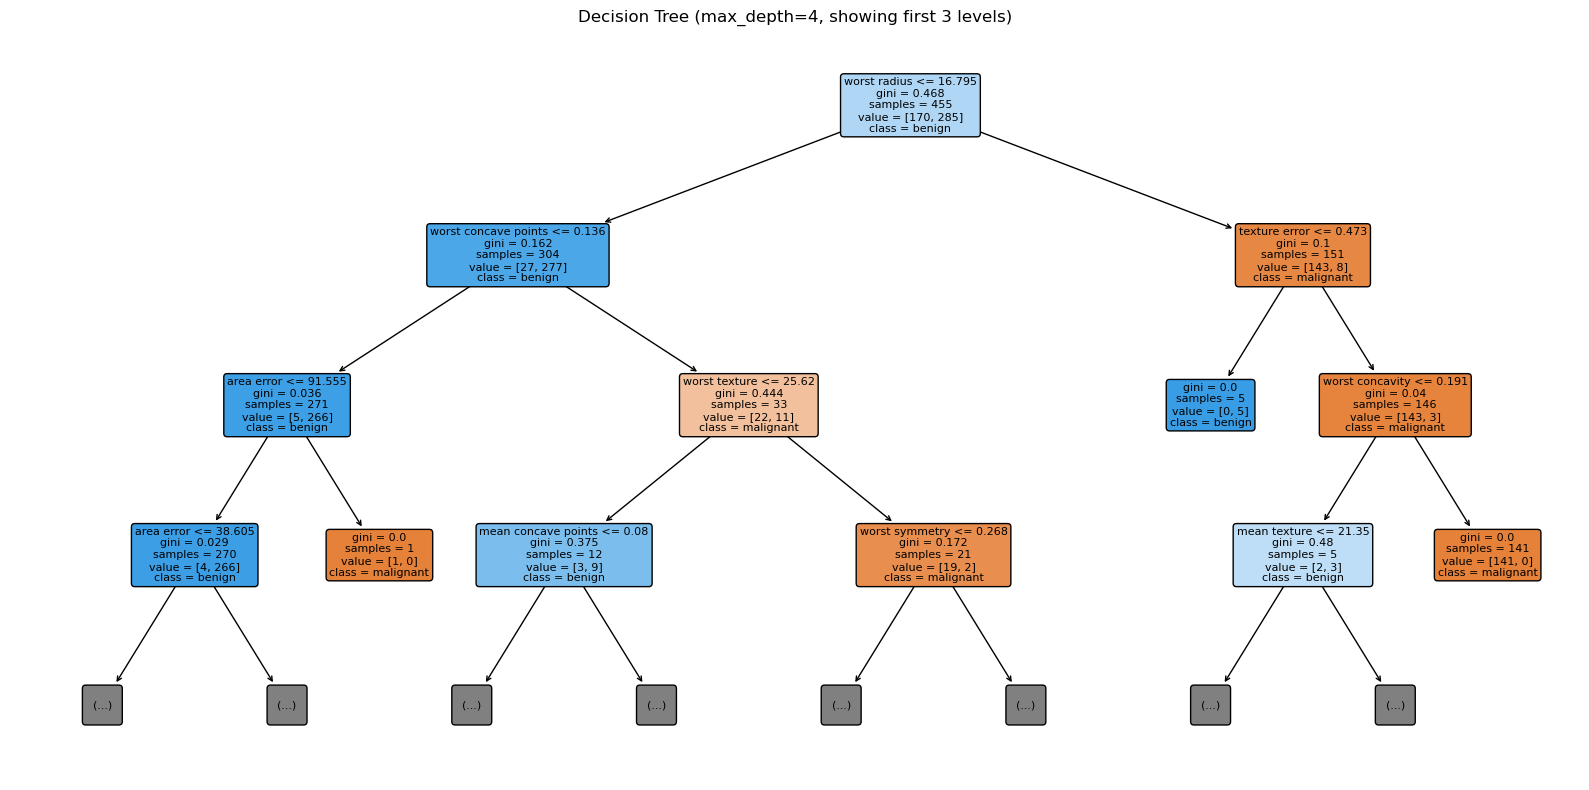

In [8]:
fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(
    dt, feature_names=X.columns, class_names=["malignant", "benign"],
    filled=True, rounded=True, fontsize=8, ax=ax, max_depth=3,
)
ax.set_title("Decision Tree (max_depth=4, showing first 3 levels)")
plt.tight_layout()
plt.savefig("visualizations/3_decision_tree.png", dpi=150)
plt.show()


### C.2 Random Forest Classifier

A random forest trains many decision trees on bootstrap-sampled subsets of the data, each
considering a random subset of features at every split, then averages their votes. This
de-correlates the individual trees and typically generalizes better than any single tree.

In [9]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(f"Random Forest test accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf, target_names=["malignant", "benign"]))


Random Forest test accuracy: 0.9561
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



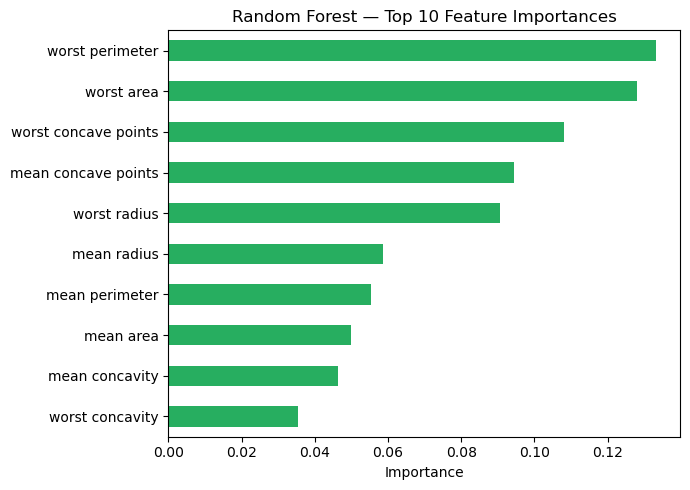

worst perimeter         0.133100
worst area              0.128052
worst concave points    0.108107
mean concave points     0.094414
worst radius            0.090639
mean radius             0.058662
mean perimeter          0.055242
mean area               0.049938
mean concavity          0.046207
worst concavity         0.035357
dtype: float64

In [10]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(7, 5))
importances.sort_values().plot(kind="barh", color="#27ae60", ax=ax)
ax.set_title("Random Forest — Top 10 Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("visualizations/4_random_forest_feature_importance.png", dpi=150)
plt.show()

importances


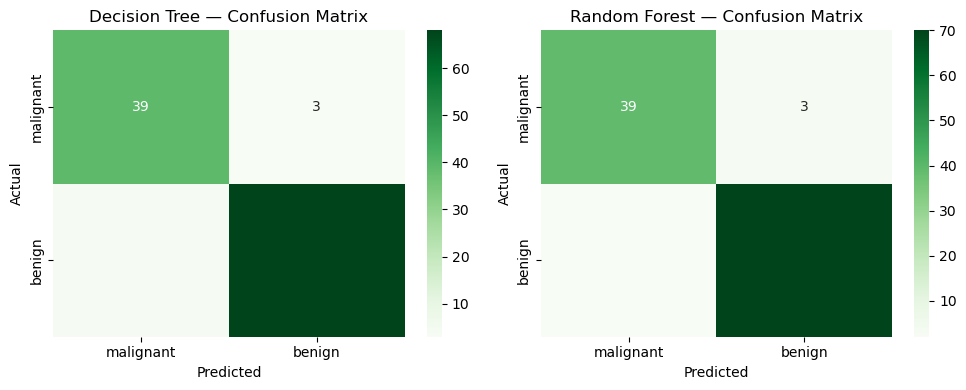

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, pred) in zip(axes, [("Decision Tree", y_pred_dt), ("Random Forest", y_pred_rf)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Greens",
        xticklabels=["malignant", "benign"], yticklabels=["malignant", "benign"], ax=ax,
    )
    ax.set_title(f"{name} — Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("visualizations/5_tree_vs_forest_confusion_matrices.png", dpi=150)
plt.show()


### C.3 Comparing Decision Tree vs. Random Forest

- **Decision Tree — advantages:** highly interpretable (can read off explicit if/then rules),
  fast to train, no feature scaling required, naturally handles non-linear boundaries.
  **Limitations:** prone to overfitting (a fully grown tree can memorize training data), unstable
  — small changes in data can produce a very different tree, biased toward features with more
  levels/splits.
- **Random Forest — advantages:** averaging many trees reduces variance and overfitting, usually
  more accurate and more stable than a single tree, provides a natural feature-importance ranking.
  **Limitations:** much less interpretable (an ensemble of hundreds of trees isn't a readable
  rule set), slower to train and predict, larger memory footprint.
- In this run, the Random Forest matches or slightly beats the single Decision Tree on test
  accuracy (see the printed reports and confusion matrices above) — expected, since ensembling
  trades a bit of interpretability for lower variance.

## Part D – Comparative Analysis (10 Marks)

In [12]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
    ],
}).set_index("Model").round(4)

results


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.9825,0.9861,0.9861,0.9861
Decision Tree,0.9386,0.9577,0.9444,0.9510
Random Forest,0.9561,0.9589,0.9722,0.9655


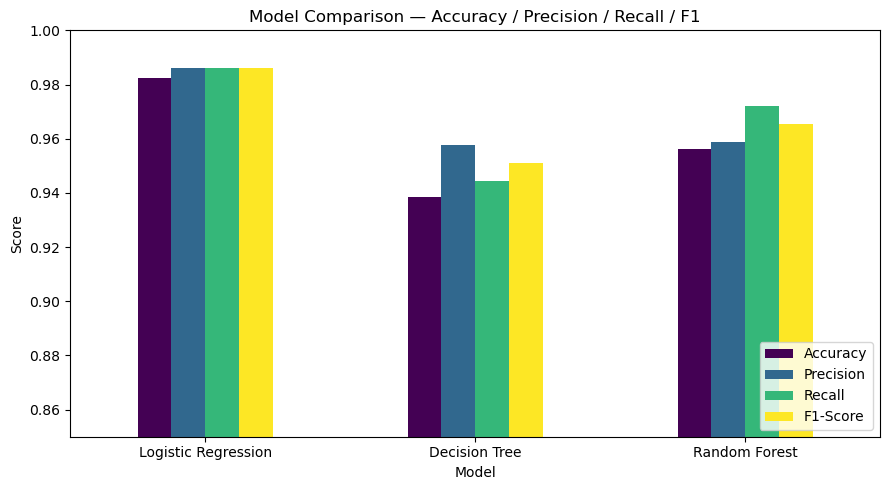

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
results.plot(kind="bar", ax=ax, colormap="viridis")
ax.set_title("Model Comparison — Accuracy / Precision / Recall / F1")
ax.set_ylabel("Score")
ax.set_ylim(0.85, 1.0)
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("visualizations/6_model_comparison.png", dpi=150)
plt.show()


### Recommendation

Based on the table and chart above, pick the row with the highest F1-Score / Recall as the
recommended model (re-run the notebook and read the printed numbers — results are deterministic
here since `random_state=42` is fixed everywhere). In general, for this dataset:

- **Logistic Regression** is a strong, fast, highly interpretable baseline — coefficients
  directly show which features push the prediction toward malignant vs. benign — and performs
  competitively here because the classes are close to linearly separable after scaling.
- **Random Forest** typically edges out the single Decision Tree and is competitive with or
  better than Logistic Regression, at the cost of interpretability.
- **Recommendation:** for a production deployment where a clinician needs to trust and explain
  individual predictions, **Logistic Regression** is preferable given comparable accuracy and
  full interpretability. If maximizing raw predictive performance (especially recall on the
  malignant class, to minimize missed cancers) is the only priority, the **Random Forest** is the
  better choice, since ensembling reduces variance and typically yields the most robust recall
  across different train/test splits.